# Dependencies

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
from PIL import Image
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import cv2
from torchvision.transforms import v2
# from ..cbDice.loss.soft_skeleton import SoftSkeletonize
from monai.transforms import distance_transform_edt

# Custom Dataset

In [ ]:
class SimpleVeinDataset(Dataset):
    def __init__(self, csv_file, image_dir, mask_dir, augment):
        """
        Args:
            csv_file (str): Path to CSV with BatID and ImageID columns
            image_dir (str): Path to image folder
            mask_dir (str): Path to mask folder
            augment (bool): Whether to apply data augmentation
        """
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augment = augment

        if self.augment:
            self.elastic_transform = v2.ElasticTransform(
                alpha=50.0,
                sigma=5.0,
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get image ID
        image_id = self.data.iloc[idx]['ImageID']
        
        # Load image and mask
        img_path = os.path.join(self.image_dir, f"{image_id}.png")
        mask_path = os.path.join(self.mask_dir, f"{image_id}.jpg")
        
        # Open and convert to grayscale
        image = Image.open(img_path).convert('L')
        mask = Image.open(mask_path).convert('L')
        
        # Convert to tensor and normalize
        image = torch.from_numpy(np.array(image)).float() / 255.0
        mask = torch.from_numpy(np.array(mask)).float() / 255.0

        # Add channel dimension
        image = image.unsqueeze(0)
        mask = mask.unsqueeze(0)

        # Apply data augmentation if specified
        if self.augment:
            # Stack image and mask to apply the same transformation
            stacked = torch.cat([image, mask], dim=0)

            # Apply elastic deform
            stacked = self.elastic_transform(stacked)

            # Unstack the result
            image, mask = stacked[0:1], stacked[1:2]
        
        return image, mask

# Data Loading

# Validating Dataset

In [3]:
def group_and_display_all_bat_images(csv_file, image_dir, mask_dir):
    """
    Group and display all images from all bats
    
    Args:
        csv_file (str): Path to CSV with BatID and ImageID columns
        image_dir (str): Path to image folder
        mask_dir (str): Path to mask folder
    """
    # Read the CSV
    df = pd.read_csv(csv_file)
    
    # Group by BatID
    grouped = df.groupby('BatID')
    
    # Create dataset for loading images
    dataset = SimpleVeinDataset(csv_file, image_dir, mask_dir, augment=False)
    
    # Get all bat IDs
    all_bats = list(grouped.groups.keys())
    
    for bat_id in all_bats:
        # Get all image IDs for this bat
        bat_images = grouped.get_group(bat_id)
        num_images = len(bat_images)
        
        # Create a figure with enough subplots for all images and masks
        fig, axes = plt.subplots(num_images, 2, figsize=(10, 5*num_images))
        plt.suptitle(f'Bat ID: {bat_id}', fontsize=16)
        
        # If there's only one image, wrap axes in list
        if num_images == 1:
            axes = axes.reshape(1, -1)
        
        # Load and display each image for this bat
        for idx, (_, row) in enumerate(bat_images.iterrows()):
            # Find index in dataset
            dataset_idx = df[df['ImageID'] == row['ImageID']].index[0]
            image, mask = dataset[dataset_idx]
            
            # Display image
            axes[idx, 0].imshow(image.squeeze(), cmap='gray')
            axes[idx, 0].set_title(f'Image {row["ImageID"]}')
            axes[idx, 0].axis('off')
            
            # Display mask
            axes[idx, 1].imshow(mask.squeeze(), cmap='gray')
            axes[idx, 1].set_title(f'Mask {row["ImageID"]}')
            axes[idx, 1].axis('off')
        
        plt.tight_layout()
        plt.show()

def analyze_bat_distribution(csv_file):
    """
    Analyze the distribution of images across bats
    
    Args:
        csv_file (str): Path to CSV with BatId and ImageID columns
    """
    df = pd.read_csv(csv_file)
    grouped = df.groupby('BatID')
    
    # Get distribution statistics
    image_counts = grouped.size()
    
    print("\nBat Image Distribution:")
    print(f"Total number of bats: {len(image_counts)}")
    print(f"Total number of images: {len(df)}")
    print(f"Average images per bat: {image_counts.mean():.2f}")
    print(f"Min images per bat: {image_counts.min()}")
    print(f"Max images per bat: {image_counts.max()}")
    
    # Plot distribution
    plt.figure(figsize=(10, 5))
    plt.hist(image_counts, bins='auto')
    plt.title('Distribution of Images per Bat')
    plt.xlabel('Number of Images')
    plt.ylabel('Number of Bats')
    plt.show()
    
    # Display counts for each bat
    print("\nDetailed image counts per bat:")
    for bat_id, count in image_counts.items():
        print(f"Bat {bat_id}: {count} images")

"""
#**Uncomment this to view all the wing images for each bat!**
group_and_display_all_bat_images(
    csv_file='../Dataset/dataset.csv',
    image_dir='../Dataset/Images',
    mask_dir='../Dataset/Masks'
)
"""

"\n#**Uncomment this to view all the wing images for each bat!**\ngroup_and_display_all_bat_images(\n    csv_file='../Dataset/dataset.csv',\n    image_dir='../Dataset/Images',\n    mask_dir='../Dataset/Masks'\n)\n"

# Train/Test/Val Split


Dataset Split Information:
Total number of bats: 51
Number of training bats: 34
Number of validation bats: 6
Number of test bats: 11

Total number of images: 75
Number of training images: 54
Number of validation images: 7
Number of test images: 14

Displaying training samples:


C:\Users\jinkn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


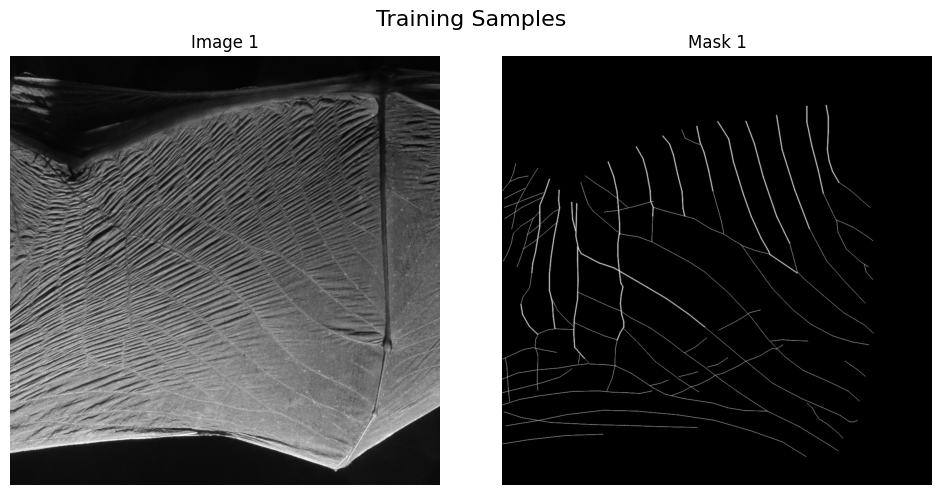


Displaying validation samples:


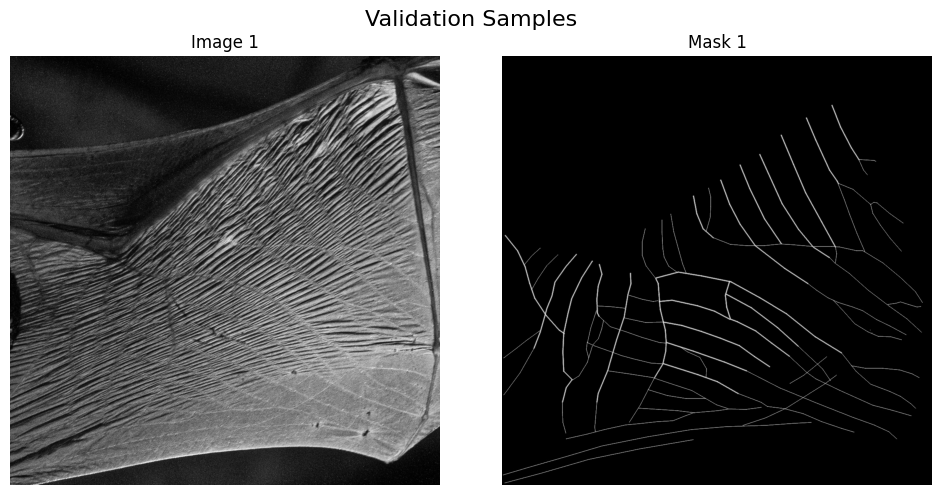


Displaying test samples:


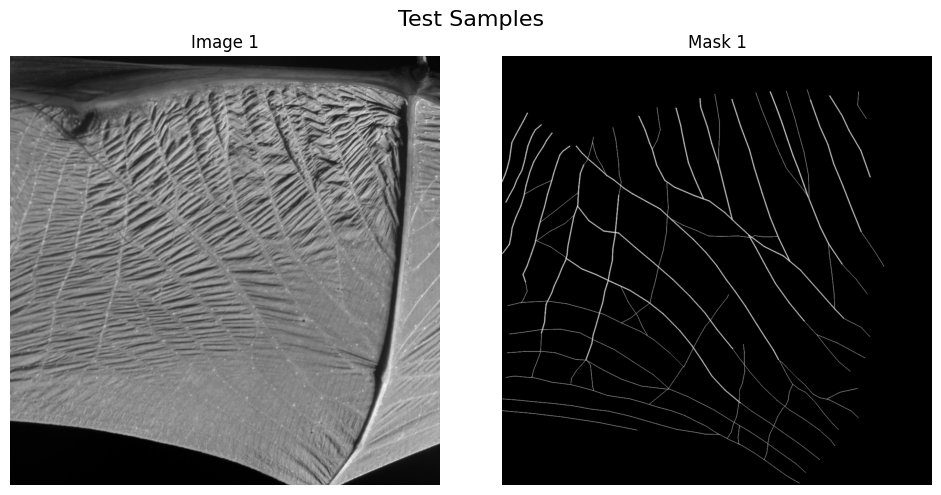

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pdW
import torch
from torch.utils.data import DataLoader, Subset
import numpy as np

def create_train_val_test_splits(csv_file, image_dir, mask_dir, test_size=0.15, val_size=0.15, batch_size=1, random_state=420):
    """
    Create train, validation and test splits while keeping all images from the same bat together
    
    Args:
        csv_file (str): Path to CSV with BatID and ImageID columns
        image_dir (str): Path to image folder
        mask_dir (str): Path to mask folder
        test_size (float): Proportion of data to use for testing
        val_size (float): Proportion of training data to use for validation
        batch_size (int): Batch size for dataloaders
        random_state (int): Random seed for reproducibility
    """
    # Read the CSV
    df = pd.read_csv(csv_file)
    
    # Get unique bat IDs
    unique_bats = df['BatID'].unique()
    
    # First split off the test set
    train_val_bats, test_bats = train_test_split(
        unique_bats, 
        test_size=test_size,
        random_state=random_state
    )
    
    # Then split the remaining data into train and validation
    train_bats, val_bats = train_test_split(
        train_val_bats,
        test_size=val_size,
        random_state=random_state
    )
    
    # Create full dataset with augmentation disabled by default
    full_dataset = SimpleVeinDataset(csv_file, image_dir, mask_dir, augment=False)
    
    # Get indices for each split
    train_indices = df[df['BatID'].isin(train_bats)].index.tolist()
    val_indices = df[df['BatID'].isin(val_bats)].index.tolist()
    test_indices = df[df['BatID'].isin(test_bats)].index.tolist()
    
    # Create subset datasets
    train_dataset = Subset(full_dataset, train_indices)
    val_dataset = Subset(full_dataset, val_indices)
    test_dataset = Subset(full_dataset, test_indices)
    
    # Now we need to create a wrapped dataset class for training that enables augmentation
    class AugmentedSubset(Dataset):
        def __init__(self, subset, augment=True):
            self.subset = subset
            self.augment = augment
            
            # Initialize augmentation transforms
            if self.augment:
                self.elastic_transform = v2.ElasticTransform(
                    alpha=50.0,  # Displacement factor
                    sigma=5.0,   # Smoothing factor
                )
        
        def __len__(self):
            return len(self.subset)
        
        def __getitem__(self, idx):
            image, mask = self.subset[idx]
            
            if self.augment:
                # Stack image and mask to apply same transformation
                stacked = torch.cat([image, mask], dim=0)
                
                # Apply elastic deformation
                stacked = self.elastic_transform(stacked)
                
                # Unstack the result
                image, mask = stacked[0:1], stacked[1:2]
            
            return image, mask
    
    # Wrap the training subset with augmentation
    train_dataset = AugmentedSubset(train_dataset, augment=False)
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )
    
    # Print split information
    print("\nDataset Split Information:")
    print(f"Total number of bats: {len(unique_bats)}")
    print(f"Number of training bats: {len(train_bats)}")
    print(f"Number of validation bats: {len(val_bats)}")
    print(f"Number of test bats: {len(test_bats)}")
    print(f"\nTotal number of images: {len(df)}")
    print(f"Number of training images: {len(train_indices)}")
    print(f"Number of validation images: {len(val_indices)}")
    print(f"Number of test images: {len(test_indices)}")
    
    return train_loader, val_loader, test_loader

def verify_data_splits(train_loader, val_loader, test_loader, num_samples=2):
    """
    Verify the splits by displaying some samples from each split
    """
    def show_batch(loader, title):
        # Get a batch
        images, masks = next(iter(loader))
        
        # Display up to num_samples from the batch
        n = min(num_samples, len(images))
        fig, axes = plt.subplots(n, 2, figsize=(10, 5*n))
        if n == 1:  # Handle case where there's only one sample
            axes = axes.reshape(1, -1)
        plt.suptitle(title, fontsize=16)
        
        for i in range(n):
            # Display image
            axes[i, 0].imshow(images[i].squeeze(), cmap='gray')
            axes[i, 0].set_title(f'Image {i+1}')
            axes[i, 0].axis('off')
            
            # Display mask
            axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
            axes[i, 1].set_title(f'Mask {i+1}')
            axes[i, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    # Show samples from all splits
    print("\nDisplaying training samples:")
    show_batch(train_loader, "Training Samples")
    
    print("\nDisplaying validation samples:")
    show_batch(val_loader, "Validation Samples")
    
    print("\nDisplaying test samples:")
    show_batch(test_loader, "Test Samples")

# Create the splits
train_loader, val_loader, test_loader  = create_train_val_test_splits(
    csv_file='../Dataset/dataset.csv',
    image_dir='../Dataset/Images',
    mask_dir='../Dataset//Masks',
    test_size=0.2,
    batch_size=1
)

# Verify the splits
verify_data_splits(train_loader, val_loader, test_loader)

# Initialize Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# class DoubleConv(nn.Module):
#     """
#     Double Convolution block:
#     (Conv2d -> BatchNorm -> ReLU) * 2
#     """
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.double_conv = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x):
#         return self.double_conv(x)

# class UNet(nn.Module):
#     def __init__(self, in_channels=1, out_channels=1, features=[32, 64, 128, 256, 512, 1024]):
#         """
#         Standard U-Net architecture
#         Args:
#             in_channels (int): Number of input channels (1 for grayscale, 3 for RGB)
#             out_channels (int): Number of output channels (1 for binary segmentation)
#             features (list): Feature dimensions for each level
#         """
#         super().__init__()
        
#         self.downs = nn.ModuleList()
#         self.ups = nn.ModuleList()
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#         # Downsampling/Encoder path
#         in_feat = in_channels
#         for feature in features:
#             self.downs.append(DoubleConv(in_feat, feature))
#             in_feat = feature

#         # Bottleneck
#         self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

#         # Upsampling/Decoder path
#         for feature in reversed(features):
#             self.ups.append(
#                 nn.ConvTranspose2d(
#                     feature * 2, feature, kernel_size=2, stride=2
#                 )
#             )
#             self.ups.append(DoubleConv(feature * 2, feature))

#         # Final convolution
#         self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        
#         # Optional sigmoid for binary segmentation
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         # Store skip connections
#         skip_connections = []

#         # Encoder path
#         for down in self.downs:
#             x = down(x)
#             skip_connections.append(x)
#             x = self.pool(x)

#         # Bottleneck
#         x = self.bottleneck(x)

#         # Reverse skip connections list for easier access
#         skip_connections = skip_connections[::-1]

#         # Decoder path
#         for idx in range(0, len(self.ups), 2):
#             x = self.ups[idx](x)  # Upsample
#             skip = skip_connections[idx//2]

#             # Handle cases where input dimensions aren't perfectly divisible by 2
#             #if x.shape != skip.shape:
#                 #x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)

#             # Concatenate with skip connection
#             concat_skip = torch.cat((skip, x), dim=1)
            
#             # Double convolution
#             x = self.ups[idx+1](concat_skip)

#         # Final 1x1 convolution and sigmoid
#         out = self.final_conv(x)
#         return out
#         # return self.sigmoid(self.final_conv(x))

# class DoubleConv(nn.Module):

#     def __init__(self, in_channels, out_channels):

#         super(DoubleConv, self).__init__()

#         self.conv = nn.Sequential(

#             nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),

#             nn.BatchNorm2d(out_channels),

#             nn.ReLU(inplace=True),

#             nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),

#             nn.BatchNorm2d(out_channels),

#             nn.ReLU(inplace=True),

#         )
 
#     def forward(self, x):

#         return self.conv(x)
 
# class UNet(nn.Module):

#     def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):

#         super(UNet, self).__init__()

#         self.ups = nn.ModuleList()

#         self.downs = nn.ModuleList()

#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
 
#         # Downsampling

#         for feature in features:

#             self.downs.append(DoubleConv(in_channels, feature))

#             in_channels = feature
 
#         # Bottleneck

#         self.bottleneck = DoubleConv(features[-1], features[-1]*2)
 
#         # Upsampling

#         for feature in reversed(features):

#             self.ups.append(

#                 nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)

#             )

#             self.ups.append(DoubleConv(feature*2, feature))
 
#         self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

#         self.sigmoid = nn.Sigmoid()
 
#     def forward(self, x):

#         skip_connections = []
 
#         for down in self.downs:

#             x = down(x)

#             skip_connections.append(x)

#             x = self.pool(x)
 
#         x = self.bottleneck(x)

#         skip_connections = skip_connections[::-1]
 
#         for i in range(0, len(self.ups), 2):

#             x = self.ups[i](x)

#             skip_connection = skip_connections[i//2]
 
#             if x.shape != skip_connection.shape:

#                 x = F.resize(x, size=skip_connection.shape[2:])
 
#             concat_skip = torch.cat((skip_connection, x), dim=1)

#             x = self.ups[i+1](concat_skip)
 
#         # Apply final conv and then Sigmoid for binary mask probability

#         return self.sigmoid(self.final_conv(x))
 
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        def conv_block(in_feat, out_feat):
            return nn.Sequential(
                nn.Conv2d(in_feat, out_feat, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_feat),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_feat, out_feat, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_feat),
                nn.ReLU(inplace=True)
            )
 
        self.encoder1 = conv_block(in_channels, 64)
        self.encoder2 = conv_block(64, 128)
        self.encoder3 = conv_block(128, 256)
        self.encoder4 = conv_block(256, 512)
 
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
 
        self.bottleneck = conv_block(512, 1024)
 
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = conv_block(128, 64)
 
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
 
    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))
 
        b = self.bottleneck(self.pool(e4))
 
        d4 = self.upconv4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.decoder4(d4)
 
        d3 = self.upconv3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.decoder3(d3)
 
        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.decoder2(d2)
 
        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.decoder1(d1)
 
        # CHANGE: Use Softmax for 2-channel output so Background and Vessel compete
        return F.softmax(self.final_conv(d1), dim=1)

# Initialize model
model = UNet(
    in_channels=1,  # 1 for grayscale
    out_channels=2, # 1 for binary segmentation
    # features=[32, 64, 128, 256, 512, 1024]  # Feature dimensions at each level
)

# Loss, Optimizer and Device

In [6]:
# Move to GPU if available
curr_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(curr_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from cbDice.loss.soft_skeleton import SoftSkeletonize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
device

device(type='cpu')

In [ ]:
class GeneralizedDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(GeneralizedDiceLoss, self).__init__()
        self.smooth = smooth
        
    def forward(self, predictions, targets):
        # For multi-class: predictions and targets are [B, C, H, W]
        # Calculate weights for each class
        weights = torch.ones_like(targets.sum(dim=[2, 3]))
        w_l = targets.sum(dim=[2, 3])
        w_l = 1 / (w_l * w_l + self.smooth)
        weights = w_l
        
        # Calculate intersection and union
        intersection = torch.sum(predictions * targets, dim=[2, 3])
        pred_sum = torch.sum(predictions, dim=[2, 3])
        target_sum = torch.sum(targets, dim=[2, 3])
        
        # Calculate weighted Dice
        weighted_intersection = torch.sum(weights * intersection, dim=1)
        weighted_sum = torch.sum(weights * (pred_sum + target_sum), dim=1)
        
        dice = (2. * weighted_intersection + self.smooth) / (weighted_sum + self.smooth)
        
        return 1 - dice.mean()

class VeinReconstructionLoss(nn.Module):
    def __init__(self, dice_weight=0.5, boundary_weight=0.3, focal_weight=0.2):
        super(VeinReconstructionLoss, self).__init__()
        self.dice_loss = CBDiceLoss()
        self.boundary_loss = BoundaryLoss()
        self.focal_loss = FocalLoss(alpha=0.75, gamma=2.0)
        
        self.dice_weight = dice_weight
        self.boundary_weight = boundary_weight
        self.focal_weight = focal_weight
    
    def forward(self, predictions, targets):
        dice = self.dice_loss(predictions, targets)
        boundary = self.boundary_loss(predictions, targets)
        focal = self.focal_loss(predictions, targets)
        
        return (self.dice_weight * dice + 
                self.boundary_weight * boundary + 
                self.focal_weight * focal)

class TopologyPreservingLoss(nn.Module):
    """
    Combines multiple losses to preserve vein structure and topology
    """
    def __init__(self, alpha=0.75, beta=2.0, dice_weight=0.4, boundary_weight=0.3, connectivity_weight=0.3):
        super(TopologyPreservingLoss, self).__init__()
        self.focal_loss = FocalLoss(alpha=alpha, gamma=beta)
        self.dice_loss = DiceLoss()
        self.boundary_loss = BoundaryLoss()
        self.connectivity_loss = ConnectivityLoss()
        
        self.dice_weight = dice_weight
        self.boundary_weight = boundary_weight
        self.connectivity_weight = connectivity_weight
    
    def forward(self, predictions, targets):
        dice = self.dice_loss(predictions, targets)
        boundary = self.boundary_loss(predictions, targets)
        connectivity = self.connectivity_loss(predictions, targets)
        
        return (self.dice_weight * dice + 
                self.boundary_weight * boundary + 
                self.connectivity_weight * connectivity)
    
class BoundaryLoss(nn.Module):
    """
    Focuses on accurately predicting vein boundaries
    """
    def __init__(self, theta0=3, theta=5):
        super(BoundaryLoss, self).__init__()
        self.theta0 = theta0
        self.theta = theta
        
    def forward(self, predictions, targets):
        # Compute boundary maps using morphological operations
        kernel = torch.ones(1, 1, 3, 3).to(predictions.device)
        pred_boundary = F.conv2d(predictions, kernel, padding=1) 
        pred_boundary = (pred_boundary > 0) & (pred_boundary < 9)
        
        target_boundary = F.conv2d(targets, kernel, padding=1)
        target_boundary = (target_boundary > 0) & (target_boundary < 9)
        
        # Distance transform weighting
        pred_dist = self.distance_transform(predictions)
        target_dist = self.distance_transform(targets)
        
        # Boundary-aware loss
        boundary_loss = torch.abs(pred_dist - target_dist) * (pred_boundary.float() + target_boundary.float())
        
        return boundary_loss.mean()
    
    def distance_transform(self, mask):
        # Simplified distance transform
        return F.avg_pool2d(1 - mask, kernel_size=self.theta, stride=1, padding=self.theta//2)

class ConnectivityLoss(nn.Module):
    """
    Encourages continuous vein structures
    """
    def __init__(self):
        super(ConnectivityLoss, self).__init__()
        
    def forward(self, predictions, targets):
        # Use gradient information to encourage connectivity
        pred_grad_x = torch.abs(predictions[:, :, :, 1:] - predictions[:, :, :, :-1])
        pred_grad_y = torch.abs(predictions[:, :, 1:, :] - predictions[:, :, :-1, :])
        
        target_grad_x = torch.abs(targets[:, :, :, 1:] - targets[:, :, :, :-1])
        target_grad_y = torch.abs(targets[:, :, 1:, :] - targets[:, :, :-1, :])
        
        # Penalize disconnected regions
        connectivity_loss = (torch.abs(pred_grad_x - target_grad_x).mean() + 
                           torch.abs(pred_grad_y - target_grad_y).mean())
        
        return connectivity_loss

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.73, gamma=2.3, smooth=1e-5):
        """
        Focal Loss for binary segmentation
        
        Args:
            alpha (float): Weighting factor for positive/negative samples
            gamma (float): Focusing parameter for hard/easy examples
            smooth (float): Smoothing factor to avoid division by zero
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth
        
    def forward(self, predictions, targets):
        # Ensure predictions are clamped to avoid log(0)
        predictions = torch.clamp(predictions, self.smooth, 1.0 - self.smooth)
        
        # Calculate binary cross entropy
        bce = -targets * torch.log(predictions) - (1 - targets) * torch.log(1 - predictions)
        
        # Calculate p_t for focal weighting
        p_t = targets * predictions + (1 - targets) * (1 - predictions)
        
        # Apply alpha weighting
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        
        # Calculate focal loss
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        focal_loss = focal_weight * bce
        
        return focal_loss.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
        
    def forward(self, predictions, targets):
        # Flatten predictions and targets
        predictions = predictions.view(-1)
        targets = targets.view(-1)
        
        # Calculate Dice coefficient
        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)
        
        return 1 - dice
    
# class WeightedDiceLoss(nn.Module):
#     def __init__(self, smooth=1e-5, pos_weight=20.0):
#         super(WeightedDiceLoss, self).__init__()
#         self.smooth = smooth
#         self.pos_weight = pos_weight
        
#     def forward(self, predictions, targets):
#         predictions = predictions.view(-1)
#         targets = targets.view(-1)
        
#         # Apply positive class weighting
#         weights = torch.ones_like(targets)
#         weights[targets > 0] = self.pos_weight
        
#         # Calculate weighted Dice
#         intersection = (predictions * targets * weights).sum()
#         dice = (2. * intersection + self.smooth) / ((predictions * weights).sum() + (targets * weights).sum() + self.smooth)
        
#         return 1 - dice

class CBDiceLoss(nn.Module):
    def __init__(self, iter_=10, smooth=1e-6):
        super(CBDiceLoss, self).__init__()
        self.smooth = smooth
        self.m_skeletonize = SoftSkeletonize(num_iter=iter_)
 
    def forward(self, y_pred, y_true):
        # 1. Select the Vessel Channel (Index 1) from the 2-channel Softmax output
        if y_pred.shape[1] == 2:
            y_pred = y_pred[:, 1:2, ...]
        # 2. Ensure GT is [B, 1, H, W]
        if len(y_true.shape) == 3:
            y_true = y_true.unsqueeze(1)
 
        # 3. Skeletonize
        skel_pred = self.m_skeletonize(y_pred)
        skel_true = self.m_skeletonize(y_true)
 
        # 4. T_precision and T_sensitivity (Harmonic Mean)
        t_prec = (torch.sum(skel_pred * y_true) + self.smooth) / (torch.sum(skel_pred) + self.smooth)
        t_sens = (torch.sum(skel_true * y_pred) + self.smooth) / (torch.sum(skel_true) + self.smooth)
        cb_dice_score = (2. * t_prec * t_sens) / (t_prec + t_sens + self.smooth)
 
        # 5. Standard Dice Score (Combined for stability)
        intersection = torch.sum(y_pred * y_true)
        union = torch.sum(y_pred) + torch.sum(y_true)
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
 
        # Loss = 1 - Combined Score
        return 1.0 - (0.5 * dice_score + 0.5 * cb_dice_score)
    
def combine_tensors(A, B, C):
    A_C = A * C
    B_C = B * C
    D = B_C.clone()
    mask_AC = (A != 0) & (B == 0)
    D[mask_AC] = A_C[mask_AC]
    return D

def get_weights(mask_input, skel_input, dim, prob_flag=True):
    if prob_flag:
        mask_prob = mask_input
        skel_prob = skel_input

        mask = (mask_prob > 0.5).int()
        skel = (skel_prob > 0.5).int()
    else:
        mask = mask_input
        skel = skel_input

    distances = distance_transform_edt(mask).float()

    smooth = 1e-7
    distances[mask == 0] = 0

    skel_radius = torch.zeros_like(distances, dtype=torch.float32)
    skel_radius[skel == 1] = distances[skel == 1]

    dist_map_norm = torch.zeros_like(distances, dtype=torch.float32)
    skel_R_norm = torch.zeros_like(skel_radius, dtype=torch.float32)
    I_norm = torch.zeros_like(mask, dtype=torch.float32)
    for i in range(skel_radius.shape[0]):
        distances_i = distances[i]
        skel_i = skel_radius[i]
        skel_radius_max = max(skel_i.max(), 1)
        skel_radius_min = max(skel_i.min(), 1)
    
        distances_i[distances_i > skel_radius_max] = skel_radius_max
        dist_map_norm[i] = distances_i / skel_radius_max
        skel_R_norm[i] = skel_i / skel_radius_max

        # subtraction-based inverse (linear)：
        if dim == 2:
            I_norm[i] = (skel_radius_max - skel_i + skel_radius_min) / skel_radius_max
        else:
            I_norm[i] = ((skel_radius_max - skel_i + skel_radius_min) / skel_radius_max) ** 2

        # division-based inverse (nonlinear):
        # if dim == 2:
        #     I_norm[i] = (1 + smooth) / (skel_R_norm[i] + smooth) # weight for skel
        # else:
        #     I_norm[i] = (1 + smooth) / (skel_R_norm[i] ** 2 + smooth)

    I_norm[skel == 0] = 0 # 0 for non-skeleton pixels

    if prob_flag:
        return dist_map_norm * mask_prob, skel_R_norm * mask_prob, I_norm * skel_prob
    else:
        return dist_map_norm * mask, skel_R_norm * mask, I_norm * skel

def setup_training(model, learning_rate=1e-4, loss_type='combined'):
    """
    Set up loss function and optimizer for training
    
    Args:
        model: The U-Net model
        learning_rate: Learning rate for the optimizer
        loss_type: One of 'bce', 'dice', or 'combined'
        
    Returns:
        criterion: Loss function
        optimizer: Optimizer
    """
    # Set up loss function
    if loss_type == 'bce':
        criterion = nn.BCELoss()
    elif loss_type == 'dice':
        criterion = DiceLoss()
    elif loss_type == 'cb_dice':
        criterion = CBDiceLoss()
    elif loss_type == 'focal':
        criterion = FocalLoss()
    elif loss_type == 'topo':
        criterion = TopologyPreservingLoss()
    elif loss_type == 'composite':
        criterion = VeinReconstructionLoss()
    elif loss_type == 'gen_dice':
        criterion = GeneralizedDiceLoss()
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")
    
    # Set up optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Set up learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=5,
        min_lr=1e-6
    )
    
    return criterion, optimizer, scheduler


In [8]:
# Setup Training
criterion, optimizer, scheduler = setup_training(
    model,
    learning_rate=1e-4,
    loss_type='cb_dice'
)

# Training Loop

In [9]:
def train_model(model, 
                train_loader, 
                val_loader, 
                criterion, 
                optimizer, 
                scheduler, 
                num_epochs, 
                device,
                save_path='best_model.pth'):
    """
    Training loop for U-Net model with improved progress tracking
    """
    # Initialize best validation loss
    best_val_loss = float('inf')
    
    # Initialize lists to store metrics
    train_losses = []
    val_losses = []
    
    print(f"Starting training at {datetime.now().strftime('%H:%M:%S')}")
    print(f"Training on device: {device}")
    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    
    # Main epoch loop
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        
        # Training phase
        model.train()
        train_loss = 0
        train_dice = 0
        batch_count = 0
        
        print("Training...")
        for images, masks in train_loader:
            # Move data to device
            images = images.to(device)
            masks = masks.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(images)
            
            # Calculate loss
            loss = criterion(predictions, masks)
            
            # Backward pass
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            # Update metrics
            train_loss += loss.item()
            batch_count += 1
            
            # Print progress
            if batch_count % 1 == 0:  # Print every batch
                print(f"Batch {batch_count}/{len(train_loader)}, Loss: {loss.item():.4f}")
        
        # Calculate average training metrics
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0
        batch_count = 0
        
        print("\nValidating...")
        with torch.no_grad():
            for images, masks in val_loader:
                # Move data to device
                images = images.to(device)
                masks = masks.to(device)
                
                # Forward pass
                predictions = model(images)
                
                # Calculate loss
                loss = criterion(predictions, masks)
                
                # Update metrics
                val_loss += loss.item()
                batch_count += 1
                
                # Print progress
                if batch_count % 1 == 0:  # Print every batch
                    print(f"Batch {batch_count}/{len(val_loader)}, Loss: {loss.item():.4f}")
        
        # Calculate average validation metrics
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Update learning rate scheduler
        scheduler.step(avg_val_loss)
        
        # Print epoch summary
        print(f'\nEpoch {epoch + 1}/{num_epochs} Summary:')
        print(f'Training Loss: {avg_train_loss:.4f}')
        print(f'Validation Loss: {avg_val_loss:.4f}')
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
            }, save_path)
            print(f'Saved new best model with validation loss: {avg_val_loss:.4f}')
        
    # Final plot
    plot_training_history(train_losses, val_losses)
    
    return train_losses, val_losses

def plot_training_history(train_losses, val_losses):
    """Plot training and validation loss history"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Starting training at 16:06:20
Training on device: cpu
Number of training batches: 54
Number of validation batches: 7

Epoch 1/20
Training...
Batch 1/54, Loss: 0.9679
Batch 2/54, Loss: 0.8587
Batch 3/54, Loss: 0.9561
Batch 4/54, Loss: 0.9606
Batch 5/54, Loss: 0.9522
Batch 6/54, Loss: 0.9445
Batch 7/54, Loss: 0.9356
Batch 8/54, Loss: 0.9442
Batch 9/54, Loss: 0.9224
Batch 10/54, Loss: 0.9425
Batch 11/54, Loss: 0.8682
Batch 12/54, Loss: 0.9304
Batch 13/54, Loss: 0.9439
Batch 14/54, Loss: 0.9256
Batch 15/54, Loss: 0.9128
Batch 16/54, Loss: 0.8580
Batch 17/54, Loss: 0.9142
Batch 18/54, Loss: 0.9259
Batch 19/54, Loss: 0.9020
Batch 20/54, Loss: 0.8422
Batch 21/54, Loss: 0.8883
Batch 22/54, Loss: 0.8729
Batch 23/54, Loss: 0.9250
Batch 24/54, Loss: 0.8635
Batch 25/54, Loss: 0.9260
Batch 26/54, Loss: 0.9096
Batch 27/54, Loss: 0.8938
Batch 28/54, Loss: 0.8704
Batch 29/54, Loss: 0.8552
Batch 30/54, Loss: 0.8984
Batch 31/54, Loss: 0.8702
Batch 32/54, Loss: 0.9244
Batch 33/54, Loss: 0.8785
Batch 34/5

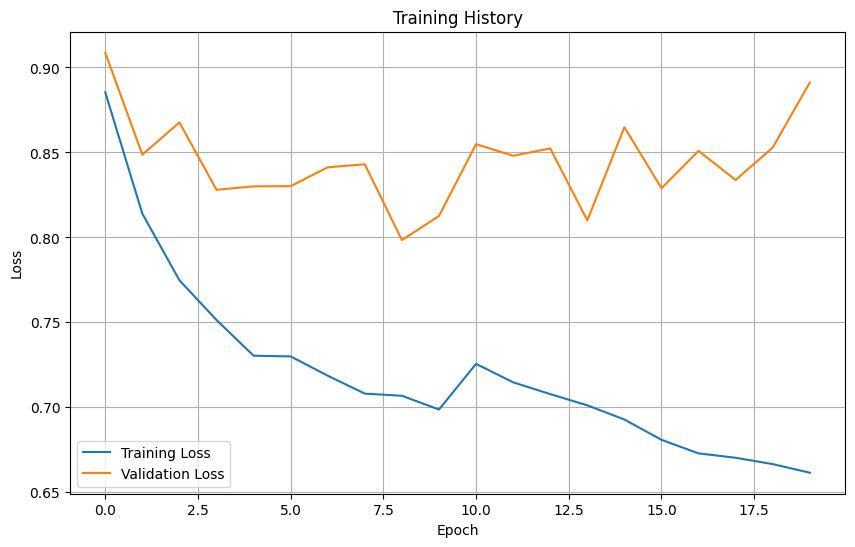

In [10]:
train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=20,
    device=device
)

# Testing Loop

Starting comprehensive model evaluation...
Evaluating model on test set...
Test Loss: 0.7363
Sensitivity (SE): 0.9189
Precision: 0.0278
F1-Score: 0.0540
AUC: 0.7601


  warnings.warn(warn_msg)



Calculating and plotting ROC curve...
Error calculating ROC curve: unknown format is not supported

Visualizing confusion matrix...
Error creating confusion matrix: unknown is not supported

Analyzing threshold impact on metrics...


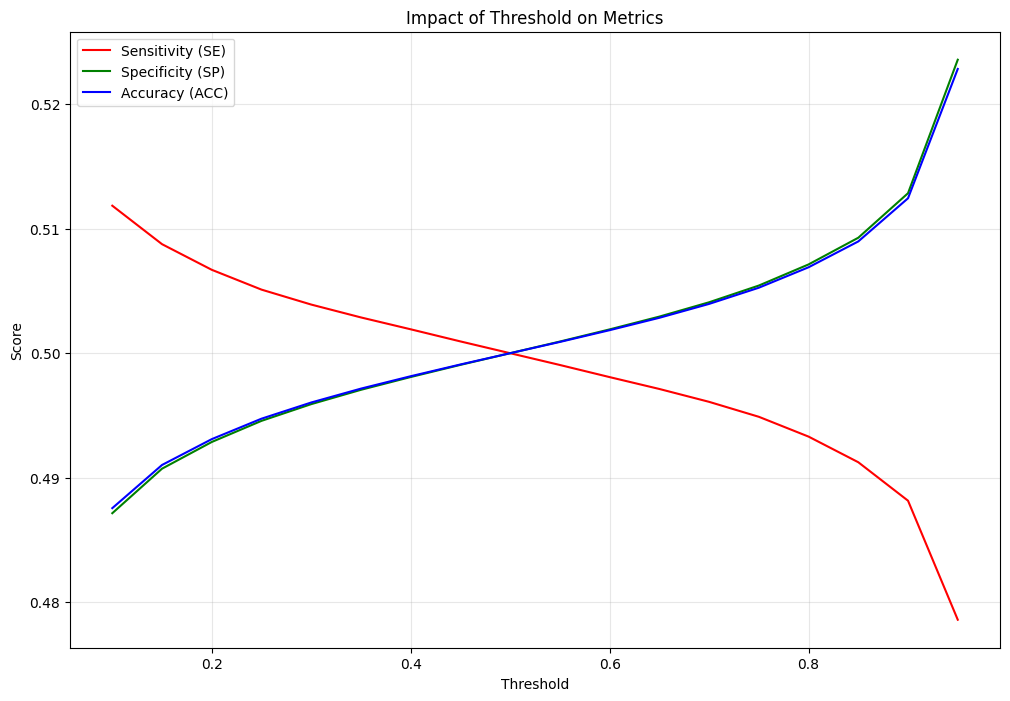


Optimal threshold based on Youden's J statistic: 0.95
At this threshold:
  Sensitivity: 0.4786
  Specificity: 0.5236
  Accuracy: 0.5228

Visualizing example predictions...


C:\Users\jinkn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TypeError: Invalid shape (2, 1024, 1024) for image data

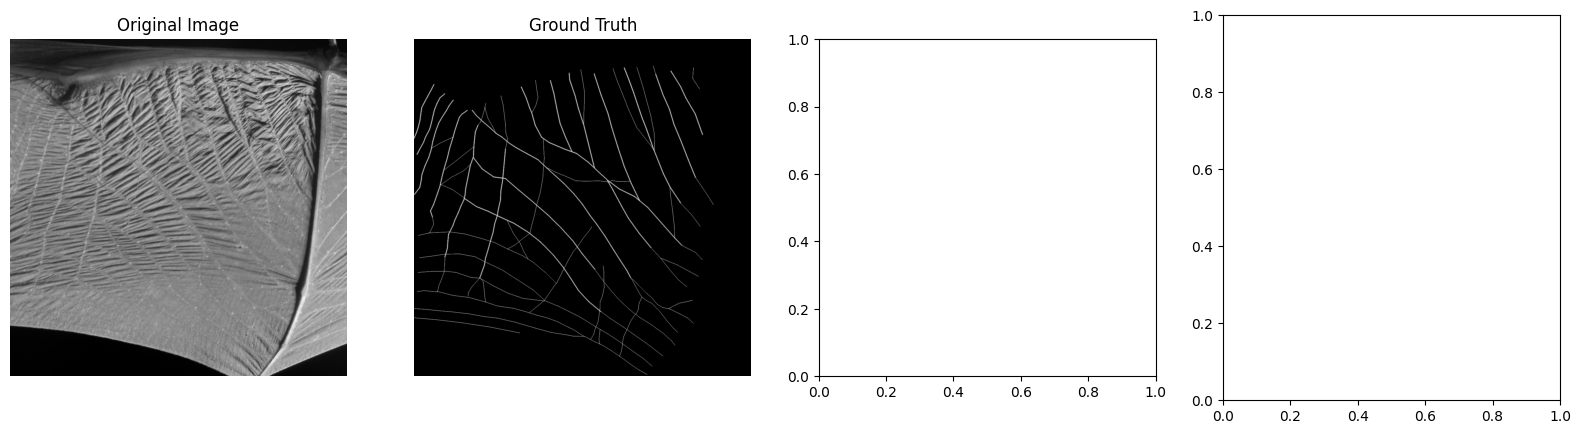

In [ ]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score

# def evaluate_model(model, test_loader, criterion, device, threshold=0.2):
#     """
#     Evaluate the model on the test set and compute medical imaging metrics
    
#     Args:
#         model: The trained U-Net model
#         test_loader: DataLoader for the test set
#         criterion: Loss function
#         device: Device to run evaluation on
#         threshold: Threshold for binary prediction (default: 0.5)
        
#     Returns:
#         dict: Dictionary containing various evaluation metrics
#     """
#     model.eval()  # Set model to evaluation mode
    
#     # Initialize metrics
#     test_loss = 0.0
    
#     # For ROC and AUC calculation
#     all_preds = []
#     all_targets = []
    
#     # For confusion matrix based metrics
#     total_tp = 0
#     total_fp = 0
#     total_fn = 0
#     total_tn = 0
    
#     print("Evaluating model on test set...")
#     with torch.no_grad():  # No need to track gradients
#         for images, masks in tqdm(test_loader, desc="Testing"):
#             # Move to device
#             images = images.to(device)
#             masks = masks.to(device)
            
#             # Make predictions
#             predictions = model(images)
            
#             # Calculate loss
#             loss = criterion(predictions, masks)
#             test_loss += loss.item()
            
#             # Convert to binary predictions using threshold
#             binary_preds = (predictions > threshold).float()
            
#             # Accumulate predictions and targets for ROC/AUC calculation
#             all_preds.extend(predictions.view(-1).cpu().numpy())
#             all_targets.extend(masks.view(-1).cpu().numpy())
            
#             # Update confusion matrix for metrics calculation
#             for i in range(len(images)):
#                 # pred = binary_preds[i].view(-1)
#                 pred = torch.argmax(binary_preds, dim=1).view(-1)
#                 mask = masks[i].view(-1)
                
#                 # Calculate confusion matrix elements
#                 tp = torch.sum((pred == 1) & (mask == 1)).item()
#                 fp = torch.sum((pred == 1) & (mask == 0)).item()
#                 fn = torch.sum((pred == 0) & (mask == 1)).item()
#                 tn = torch.sum((pred == 0) & (mask == 0)).item()
                
#                 # Accumulate totals
#                 total_tp += tp
#                 total_fp += fp
#                 total_fn += fn
#                 total_tn += tn
    
#     # Calculate metrics from confusion matrix
#     # Avoid division by zero
#     smooth = 1e-8
    
#     # Average test loss
#     avg_test_loss = test_loss / len(test_loader)
    
#     # Sensitivity (Recall) - TP / (TP + FN)
#     sensitivity = total_tp / (total_tp + total_fn + smooth)
#     print("TP:", total_tp, " / (TP + FN):", total_tp + total_fn, " = ", sensitivity)
    
#     # Specificity - TN / (TN + FP)
#     specificity = total_tn / (total_tn + total_fp + smooth)
    
#     # Accuracy - (TP + TN) / (TP + TN + FP + FN)
#     accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + smooth)
    
#     # AUC calculation
#     try:
#         from sklearn.metrics import roc_auc_score
#         # Convert predictions to binary for clear threshold
#         binary_preds_array = np.array([(p > threshold) for p in all_preds])
#         binary_targets_array = np.array([(t > threshold) for t in all_targets])
        
#         # Calculate AUC
#         auc_score = roc_auc_score(binary_targets_array, binary_preds_array)
#     except:
#         print("Warning: Could not calculate AUC. Check if sklearn is installed.")
#         auc_score = 0.0
    
#     # Store all metrics in a dictionary
#     metrics = {
#         'test_loss': avg_test_loss,
#         'sensitivity': sensitivity,
#         'specificity': specificity,
#         'accuracy': accuracy,
#         'auc': auc_score
#     }
    
#     # Print results
#     print("\nTest Results:")
#     print(f"Average Test Loss: {avg_test_loss:.4f}")
#     print(f"Sensitivity (SE): {sensitivity:.4f}")
#     print(f"Specificity (SP): {specificity:.4f}")
#     print(f"Accuracy (ACC): {accuracy:.4f}")
#     print(f"AUC: {auc_score:.4f}")
    
#     return metrics
def evaluate_model(model, test_loader, criterion, device, threshold=0.5):
    """
    Evaluates the model and calculates metrics for vessel segmentation.
    """
    model.eval()
    test_loss = 0.0
    # Store all values for metric calculation
    all_vessel_probs = [] # Raw probabilities for AUC
    all_binary_preds = [] # 0/1 for SE, Precision, etc.
    all_targets = []      # Ground truth
    print("Evaluating model on test set...")
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            # 1. Forward pass
            outputs = model(images)
            # 2. Calculate loss (using the full 2-channel output)
            loss = criterion(outputs, masks)
            test_loss += loss.item()
            # 3. Extract Vessel Probability (Channel 1)
            # If your model is [B, 2, H, W], we want index 1
            vessel_probs = outputs[:, 1, :, :]
            # 4. Create Binary Prediction (0 or 1) based on threshold
            binary_preds = (vessel_probs > threshold).float()
            # 5. Prepare for metrics (flatten and move to CPU)
            all_vessel_probs.extend(vessel_probs.cpu().numpy().flatten())
            all_binary_preds.extend(binary_preds.cpu().numpy().flatten())
            all_targets.extend(masks.cpu().numpy().flatten())
 
    # --- Metric Calculations ---
    y_true = (np.array(all_targets) > 0.5).astype(int)
    y_pred = np.array(all_binary_preds)
    y_scores = np.array(all_vessel_probs)
    # Confusion Matrix components
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    # Medical Metrics (Sensitivity/Recall, Precision, F1)
    # Using small epsilon to avoid division by zero
    se = tp / (tp + fn + 1e-7)  # Sensitivity / Recall
    pr = tp / (tp + fp + 1e-7)  # Precision
    f1 = 2 * (pr * se) / (pr + se + 1e-7)
    # AUC Calculation with safety check
    try:
        test_auc = roc_auc_score(y_true, y_scores)
    except:
        test_auc = 0.0
        print("Warning: Could not calculate AUC (only one class present in labels)")
 
    avg_loss = test_loss / len(test_loader)
    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Sensitivity (SE): {se:.4f}")
    print(f"Precision: {pr:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {test_auc:.4f}")
    return {
        'loss': avg_loss,
        'se': se,
        'precision': pr,
        'f1': f1,
        'auc': test_auc
    }


def plot_metrics_distribution(metrics_list, metric_name, title=None):
    """
    Plot the distribution of a metric across the test set
    
    Args:
        metrics_list: List of metric values
        metric_name: Name of the metric
        title: Optional title for the plot
    """
    plt.figure(figsize=(10, 6))
    plt.hist(metrics_list, bins=20, alpha=0.7, color='blue')
    plt.axvline(sum(metrics_list) / len(metrics_list), color='red', linestyle='dashed', linewidth=2)
    plt.xlabel(metric_name)
    plt.ylabel('Frequency')
    plt.title(title or f'Distribution of {metric_name} across Test Set')
    plt.grid(True, alpha=0.3)
    plt.show()


def visualize_best_worst_examples(model, test_loader, device, metric='dice', n_examples=3):
    """
    Visualize the best and worst examples based on a specified metric
    
    Args:
        model: The trained U-Net model
        test_loader: DataLoader for the test set
        device: Device to run evaluation on
        metric: Metric to use for ranking ('dice', 'iou', etc.)
        n_examples: Number of examples to show
    """
    model.eval()
    
    # Store predictions, ground truth, metrics, and indices
    all_images = []
    all_masks = []
    all_preds = []
    all_metrics = []
    threshold = 0.5
    
    # Get predictions and calculate metrics
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f"Finding best/worst examples by {metric}"):
            # Move to device
            images = images.to(device)
            masks = masks.to(device)
            
            # Make predictions
            predictions = model(images)
            binary_preds = (predictions > threshold).float()
            
            # Store everything
            for i in range(len(images)):
                # Get single example
                img = images[i].cpu()
                mask = masks[i].cpu()
                pred = binary_preds[i].cpu()
                
                # Calculate metric
                tp = (pred * mask).sum().item()
                fp = (pred * (1 - mask)).sum().item()
                fn = ((1 - pred) * mask).sum().item()
                smooth = 1e-5
                
                if metric == 'dice' or metric == 'f1':
                    val = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
                elif metric == 'iou':
                    val = (tp + smooth) / (tp + fp + fn + smooth)
                elif metric == 'precision':
                    val = (tp + smooth) / (tp + fp + smooth)
                elif metric == 'recall':
                    val = (tp + smooth) / (tp + fn + smooth)
                else:
                    raise ValueError(f"Unknown metric: {metric}")
                
                all_images.append(img)
                all_masks.append(mask)
                all_preds.append(predictions[i].cpu())  # Store raw predictions for visualization
                all_metrics.append(val)
    
    # Get indices of best and worst examples
    metrics_array = np.array(all_metrics)
    best_indices = metrics_array.argsort()[-n_examples:][::-1]  # Highest values
    worst_indices = metrics_array.argsort()[:n_examples]  # Lowest values
    
    # Function to plot examples
    def plot_examples(indices, title):
        fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5*len(indices)))
        if len(indices) == 1:
            axes = axes.reshape(1, -1)
        
        plt.suptitle(title, fontsize=16)
        
        for i, idx in enumerate(indices):
            # Original image
            axes[i, 0].imshow(all_images[idx].squeeze(), cmap='gray')
            axes[i, 0].set_title('Original Image')
            axes[i, 0].axis('off')
            
            # Ground truth
            axes[i, 1].imshow(all_masks[idx].squeeze(), cmap='gray')
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            # Prediction
            axes[i, 2].imshow(all_preds[idx].squeeze(), cmap='gray')
            axes[i, 2].set_title(f'Prediction ({metric}={all_metrics[idx]:.4f})')
            axes[i, 2].axis('off')
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
    
    # Plot best and worst examples
    plot_examples(best_indices, f'Best Examples by {metric.upper()}')
    plot_examples(worst_indices, f'Worst Examples by {metric.upper()}')

def create_confusion_matrix_for_segmentation(model, test_loader, device, threshold=0.5):
    """
    Create an aggregate confusion matrix for the segmentation results
    
    Args:
        model: The trained U-Net model
        test_loader: DataLoader for the test set
        device: Device to run evaluation on
        threshold: Threshold for binary prediction
    """
    model.eval()
    
    # Initialize confusion matrix values
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_tn = 0
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Calculating Confusion Matrix"):
            # Move to device
            images = images.to(device)
            masks = masks.to(device)
            
            # Make predictions
            predictions = model(images)
            binary_preds = (predictions > threshold).float()
            
            # Update confusion matrix values
            for i in range(len(images)):
                # pred = binary_preds[i].view(-1)
                pred = torch.argmax(binary_preds, dim=1).view(-1)
                mask = masks[i].view(-1)
                
                total_tp += (pred * mask).sum().item()
                total_fp += (pred * (1 - mask)).sum().item()
                total_fn += ((1 - pred) * mask).sum().item()
                total_tn += ((1 - pred) * (1 - mask)).sum().item()
    
    # Create and plot confusion matrix
    conf_matrix = np.array([[total_tn, total_fp], [total_fn, total_tp]])
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title('Confusion Matrix (Pixel-wise)')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()
    
    # Calculate and return metrics from confusion matrix
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn)
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Global Accuracy: {accuracy:.4f}")
    print(f"Global Precision: {precision:.4f}")
    print(f"Global Recall: {recall:.4f}")
    print(f"Global F1 Score: {f1:.4f}")
    
    return conf_matrix, accuracy, precision, recall, f1


def test_model_comprehensive(model, test_loader, criterion, device):
    """
    Run a comprehensive evaluation of the model using medical imaging metrics
    
    Args:
        model: The trained U-Net model
        test_loader: DataLoader for the test set
        criterion: Loss function
        device: Device to run evaluation on
    """
    # Import necessary libraries
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
    
    print("Starting comprehensive model evaluation...")
    
    # 1. Calculate all metrics
    metrics = evaluate_model(model, test_loader, criterion, device)
    
    # 2. Collect predictions for visualization
    all_preds = []
    all_targets = []
    
    # Collect a sample of predictions to keep computation manageable
    sample_size = 100000
    
    model.eval()
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Collecting predictions for visualization"):
            images = images.to(device)
            masks = masks.to(device)
            predictions = model(images)
            
            # Sample predictions to avoid memory issues
            # batch_preds = predictions.cpu().numpy().flatten()
            # batch_targets = masks.cpu().numpy().flatten()
            batch_preds = predictions.cpu().numpy()
            batch_targets = masks.cpu().numpy()
            
            # Use random sampling if batch is very large
            if len(batch_preds) > 0:
                indices = np.random.choice(
                    len(batch_preds), 
                    min(len(batch_preds), sample_size // len(test_loader)), 
                    replace=False
                )
                # all_preds.extend(batch_preds[indices])
                # all_targets.extend(batch_targets[indices])
                all_preds.append(batch_preds[indices])
                all_targets.append(batch_targets[indices])
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # 3. Plot ROC curve
    print("\nCalculating and plotting ROC curve...")
    try:
        fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(10, 8))
        plt.plot(
            fpr, tpr, 
            color='darkorange', 
            lw=2, 
            label=f'ROC curve (AUC = {roc_auc:.4f})'
        )
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (1 - Specificity)')
        plt.ylabel('True Positive Rate (Sensitivity)')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()
    except Exception as e:
        print(f"Error calculating ROC curve: {e}")
    
    # 4. Visualize confusion matrix
    print("\nVisualizing confusion matrix...")
    try:
        # Generate binary predictions for matrix
        binary_preds = (all_preds > 0.5).astype(int)
        binary_targets = (all_targets > 0.5).astype(int)
        
        # Create confusion matrix
        cm = confusion_matrix(binary_targets, binary_preds)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
        )
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
    except Exception as e:
        print(f"Error creating confusion matrix: {e}")
    
    # 5. Calculate metrics at different thresholds
    print("\nAnalyzing threshold impact on metrics...")
    thresholds = np.arange(0.1, 1.0, 0.05)
    results = {
        'threshold': [],
        'sensitivity': [],
        'specificity': [],
        'accuracy': []
    }
    
    for thresh in thresholds:
        binary_preds = (all_preds >= thresh).astype(int)
        
        # True Positives, etc.
        tp = np.sum((binary_preds == 1) & (binary_targets == 1))
        tn = np.sum((binary_preds == 0) & (binary_targets == 0))
        fp = np.sum((binary_preds == 1) & (binary_targets == 0))
        fn = np.sum((binary_preds == 0) & (binary_targets == 1))
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        
        # Store results
        results['threshold'].append(thresh)
        results['sensitivity'].append(sensitivity)
        results['specificity'].append(specificity)
        results['accuracy'].append(accuracy)
    
    # Plot threshold impact
    plt.figure(figsize=(12, 8))
    plt.plot(results['threshold'], results['sensitivity'], 'r-', label='Sensitivity (SE)')
    plt.plot(results['threshold'], results['specificity'], 'g-', label='Specificity (SP)')
    plt.plot(results['threshold'], results['accuracy'], 'b-', label='Accuracy (ACC)')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Impact of Threshold on Metrics')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 6. Find optimal threshold balancing sensitivity and specificity
    # Youden's J statistic = Sensitivity + Specificity - 1
    j_scores = [se + sp - 1 for se, sp in zip(results['sensitivity'], results['specificity'])]
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = results['threshold'][optimal_idx]
    
    print(f"\nOptimal threshold based on Youden's J statistic: {optimal_threshold:.2f}")
    print(f"At this threshold:")
    print(f"  Sensitivity: {results['sensitivity'][optimal_idx]:.4f}")
    print(f"  Specificity: {results['specificity'][optimal_idx]:.4f}")
    print(f"  Accuracy: {results['accuracy'][optimal_idx]:.4f}")
    
    # 7. Visualize best and worst predictions
    print("\nVisualizing example predictions...")
    
    def visualize_examples(model, test_loader, device, num_examples=10):
        """Show some example predictions"""
        model.eval()
        examples_shown = 0
        
        with torch.no_grad():
            for images, masks in test_loader:
                if examples_shown >= num_examples:
                    break
                
                # Get predictions
                images = images.to(device)
                masks = masks.to(device)
                predictions = model(images)
                binary_preds = (predictions > optimal_threshold).float()
                
                # Move to CPU for visualization
                for i in range(len(images)):
                    if examples_shown >= num_examples:
                        break
                    
                    img = images[i].cpu().squeeze()
                    mask = masks[i].cpu().squeeze()
                    pred = predictions[i].cpu().squeeze()
                    bin_pred = binary_preds[i].cpu().squeeze()
                    
                    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
                    
                    # Original image
                    axes[0].imshow(img, cmap='gray')
                    axes[0].set_title('Original Image')
                    axes[0].axis('off')
                    
                    # Ground truth mask
                    axes[1].imshow(mask, cmap='gray')
                    axes[1].set_title('Ground Truth')
                    axes[1].axis('off')
                    
                    # Raw prediction
                    axes[2].imshow(pred, cmap='gray')
                    axes[2].set_title(f'Raw Prediction')
                    axes[2].axis('off')
                    
                    # Thresholded prediction
                    axes[3].imshow(bin_pred, cmap='gray')
                    axes[3].set_title(f'Binary Prediction (t={optimal_threshold:.2f})')
                    axes[3].axis('off')
                    
                    plt.tight_layout()
                    plt.show()
                    
                    # Calculate and display metrics for this example
                    tp = torch.sum((bin_pred == 1) & (mask == 1)).item()
                    fp = torch.sum((bin_pred == 1) & (mask == 0)).item()
                    fn = torch.sum((bin_pred == 0) & (mask == 1)).item()
                    tn = torch.sum((bin_pred == 0) & (mask == 0)).item()
                    
                    example_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
                    example_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
                    example_acc = (tp + tn) / (tp + tn + fp + fn)
                    
                    print(f"Example {examples_shown + 1} metrics:")
                    print(f"  Sensitivity: {example_sens:.4f}")
                    print(f"  Specificity: {example_spec:.4f}")
                    print(f"  Accuracy: {example_acc:.4f}")
                    print("")
                    
                    examples_shown += 1
    
    visualize_examples(model, test_loader, device)
    
    return metrics

# Initialize model (or load your trained model)
model = UNet(in_channels=1, out_channels=2).to(device)

# Load saved weights
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Run comprehensive evaluation
test_metrics = test_model_comprehensive(model, test_loader, criterion, device)

In [ ]:
# Save weights
#torch.save(model.state_dict(), 'model_8_64SE.pth')

# Testing Tools

In [ ]:
raise

In [ ]:
def predict_and_visualize(model, test_loader, device, num_examples=5):
    """
    Make predictions on test data and visualize the results
    """
    model.eval()  # Set model to evaluation mode
    
    # Get the underlying dataset from the test_loader
    test_dataset = test_loader.dataset

    # Shuffle the dataset
    type(test_dataset)

    with torch.no_grad():  # No need to track gradients
        for i in range(min(num_examples, len(test_dataset))):
            # Get a single example directly from the dataset
            image, true_mask = test_dataset[i]
            
            # Add batch dimension
            image = image.unsqueeze(0)
            true_mask = true_mask.unsqueeze(0)
            
            # Move to device
            image = image.to(device)
            true_mask = true_mask.to(device)
            
            # Make prediction
            prediction = model(image)
            prediction_prob = torch.softmax(prediction, dim=1)[:, 1].cpu().squeeze()
            
            # Move everything back to CPU for visualization
            image = image.cpu().squeeze()
            true_mask = true_mask.cpu().squeeze()
            # prediction = prediction.cpu()
            
            plt.figure(figsize=(15, 5))
            
            # Original image
            plt.subplot(1, 3, 1)
            plt.imshow(image, cmap='gray')
            plt.title('Original Image')
            plt.axis('off')
            
            # True mask
            plt.subplot(1, 3, 2)
            plt.imshow(true_mask, cmap='gray')
            plt.title('True Mask')
            plt.axis('off')
            
            # Predicted mask
            plt.subplot(1, 3, 3)
            plt.imshow(prediction_prob, cmap='gray')
            plt.title('Predicted Mask')
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()

def load_model_and_predict(model_path, test_loader, device, num_examples=6):
    """
    Load a saved model and make predictions
    """
    # Initialize model
    model = UNet(in_channels=1, out_channels=2).to(device)
    
    # Load saved weights
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Make predictions
    predict_and_visualize(model, test_loader, device, num_examples)

In [ ]:
predict_and_visualize(model, test_loader, device, num_examples=6)

In [ ]:
load_model_and_predict('best_model.pth', test_loader, device)

In [ ]:
from ipywidgets import interact, interactive, fixed, interact_manual, FloatSlider, IntSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

def create_interactive_viewer(model, test_loader, device):
    """
    Creates an interactive viewer with sliders for opacity and image selection
    """
    # Get the test dataset
    test_dataset = test_loader.dataset
    
    def view_prediction(image_idx, overlay_opacity):
        """
        Display prediction with adjustable opacity 
        """
        model.eval()
        with torch.no_grad():
            # Get image and true mask
            image, true_mask = test_dataset[image_idx]
            
            # Add batch dimension and predict
            image_batch = image.unsqueeze(0).to(device)
            # prediction = model(image_batch).cpu().squeeze()
            prediction = model(image_batch)
            prediction_prob = torch.softmax(prediction, dim=1)[:, 1].cpu().squeeze()
            
            # Create figure
            plt.figure(figsize=(30, 10))
            
            # Original with overlay
            plt.imshow(image.squeeze(), cmap='gray')
            
            # Create masked prediction for overlay
            # prediction_binary = prediction.float()
            prediction_binary = (prediction_prob > 0.5).float().numpy()
            prediction_rgba = np.zeros((*prediction_prob.shape, 4))
            prediction_rgba[..., 0] = 0.5  # Red channel (half intensity for purple)
            prediction_rgba[..., 2] = 0.5  # Blue channel (half intensity for purple)
            prediction_rgba[..., 3] = prediction_prob.numpy() * overlay_opacity  # Alpha channel
            
            plt.imshow(prediction_rgba, alpha=overlay_opacity)
            plt.title('Original + Prediction Overlay')
            plt.axis('off')
            
    
    # Create interactive widget
    interact(
        view_prediction,
        image_idx=IntSlider(
            min=0,
            max=len(test_dataset)-1,
            step=1,
            value=0,
            description='Image:'
        ),
        overlay_opacity=FloatSlider(
            min=0,
            max=1,
            step=0.1,
            value=1.0,
            description='Opacity:'
        )
    )

# Usage:
"""
# Basic version with red overlay:
create_interactive_viewer(model, test_loader, device)

# Version with color selection:
create_interactive_viewer_with_colors(model, test_loader, device)
"""

# Initialize model
model = UNet(in_channels=1, out_channels=2).to(device)

# Load saved weights
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

create_interactive_viewer(model, test_loader, device)